In [1]:
import os
from pathlib import Path

# 定義目標路徑
target_path = '/users/lorin.ng/SURIP2026/data'

try:
    os.chdir(target_path)
    print(f"工作目錄已成功變更為: {os.getcwd()}")
except FileNotFoundError:
    print(f"錯誤：找不到目錄 {target_path}，請檢查拼字是否正確。")
except Exception as e:
    print(f"發生錯誤: {e}")

from pathlib import Path

base_dir = '/users/lorin.ng/SURIP2026/data'
os.chdir(base_dir)

indir = Path("/users/shared.user/Summer2026/cogwheel_O4_gaussian_injections/PE/IntrinsicLVCPrior/")

工作目錄已成功變更為: /users/lorin.ng/SURIP2026/data


In [7]:
import h5py

file = "processed_samples/MD_SDSS_l2_0_0_bilby_style_samples.h5"
with h5py.File(file, 'r') as f:
    # 印出最上層的所有名稱
    print("最上層的名稱列表：", list(f.keys()))

最上層的名稱列表： ['df']


In [1]:
import pandas as pd

# 讀取結果
df = pd.read_csv('../plots/bayes_factor_results.csv')

# 1. 移除 log_B 為 -inf 的列，並篩選出大於 0 的正向證據
candidates = df[df['log_B'] > 0].sort_values(by='log_B', ascending=False)

# 2. 印出最強的候選者
print("Top Lensing Candidates:")
print(candidates)

Top Lensing Candidates:
  Pair_0 Pair_1   log_B_m     log_B
0    3_0    3_1  0.855397  3.334092
1    2_0    2_1  0.469097  3.096725
2    1_0    1_1  0.056961  3.038211
3    0_0    0_1  0.490729  2.197111
4    5_0    5_1  0.537504  1.971045
5    7_0    7_1  0.388458  1.584146
6    8_0    8_1 -0.304063  1.552618
7    6_0    6_1  0.315268  1.519245
8    4_0    4_1  0.383755  1.399194


In [3]:
import pandas as pd

path_test = 'processed_samples/MD_SDSS_l2_0_0_bilby_style_samples.h5'
df = pd.read_hdf(path_test, key='df')
print(f"shape:{df.shape[1]} columns:{df.columns}")

shape:39 columns:Index(['mass_1', 'mass_2', 'spin_1z', 'spin_2z', 'iota', 'luminosity_distance',
       'ra', 'dec', 'phase', 'psi', 'geocent_time', 'lnlike', 'spin_1x',
       'spin_1y', 'spin_2x', 'spin_2y', 'theta_jn', 'a_1', 'a_2', 'tilt_1',
       'tilt_2', 'phi_12', 'phi_jl', 'mass_ratio', 'chirp_mass',
       'cos_theta_jn', 'sin_dec', 'chi_eff', 'chi_1_in_plane',
       'chi_2_in_plane', 'chi_p', 'network_optimal_snr', 'log_likelihood',
       'total_mass', 'redshift', 'mass_1_source', 'mass_2_source',
       'chirp_mass_source', 'total_mass_source'],
      dtype='object')


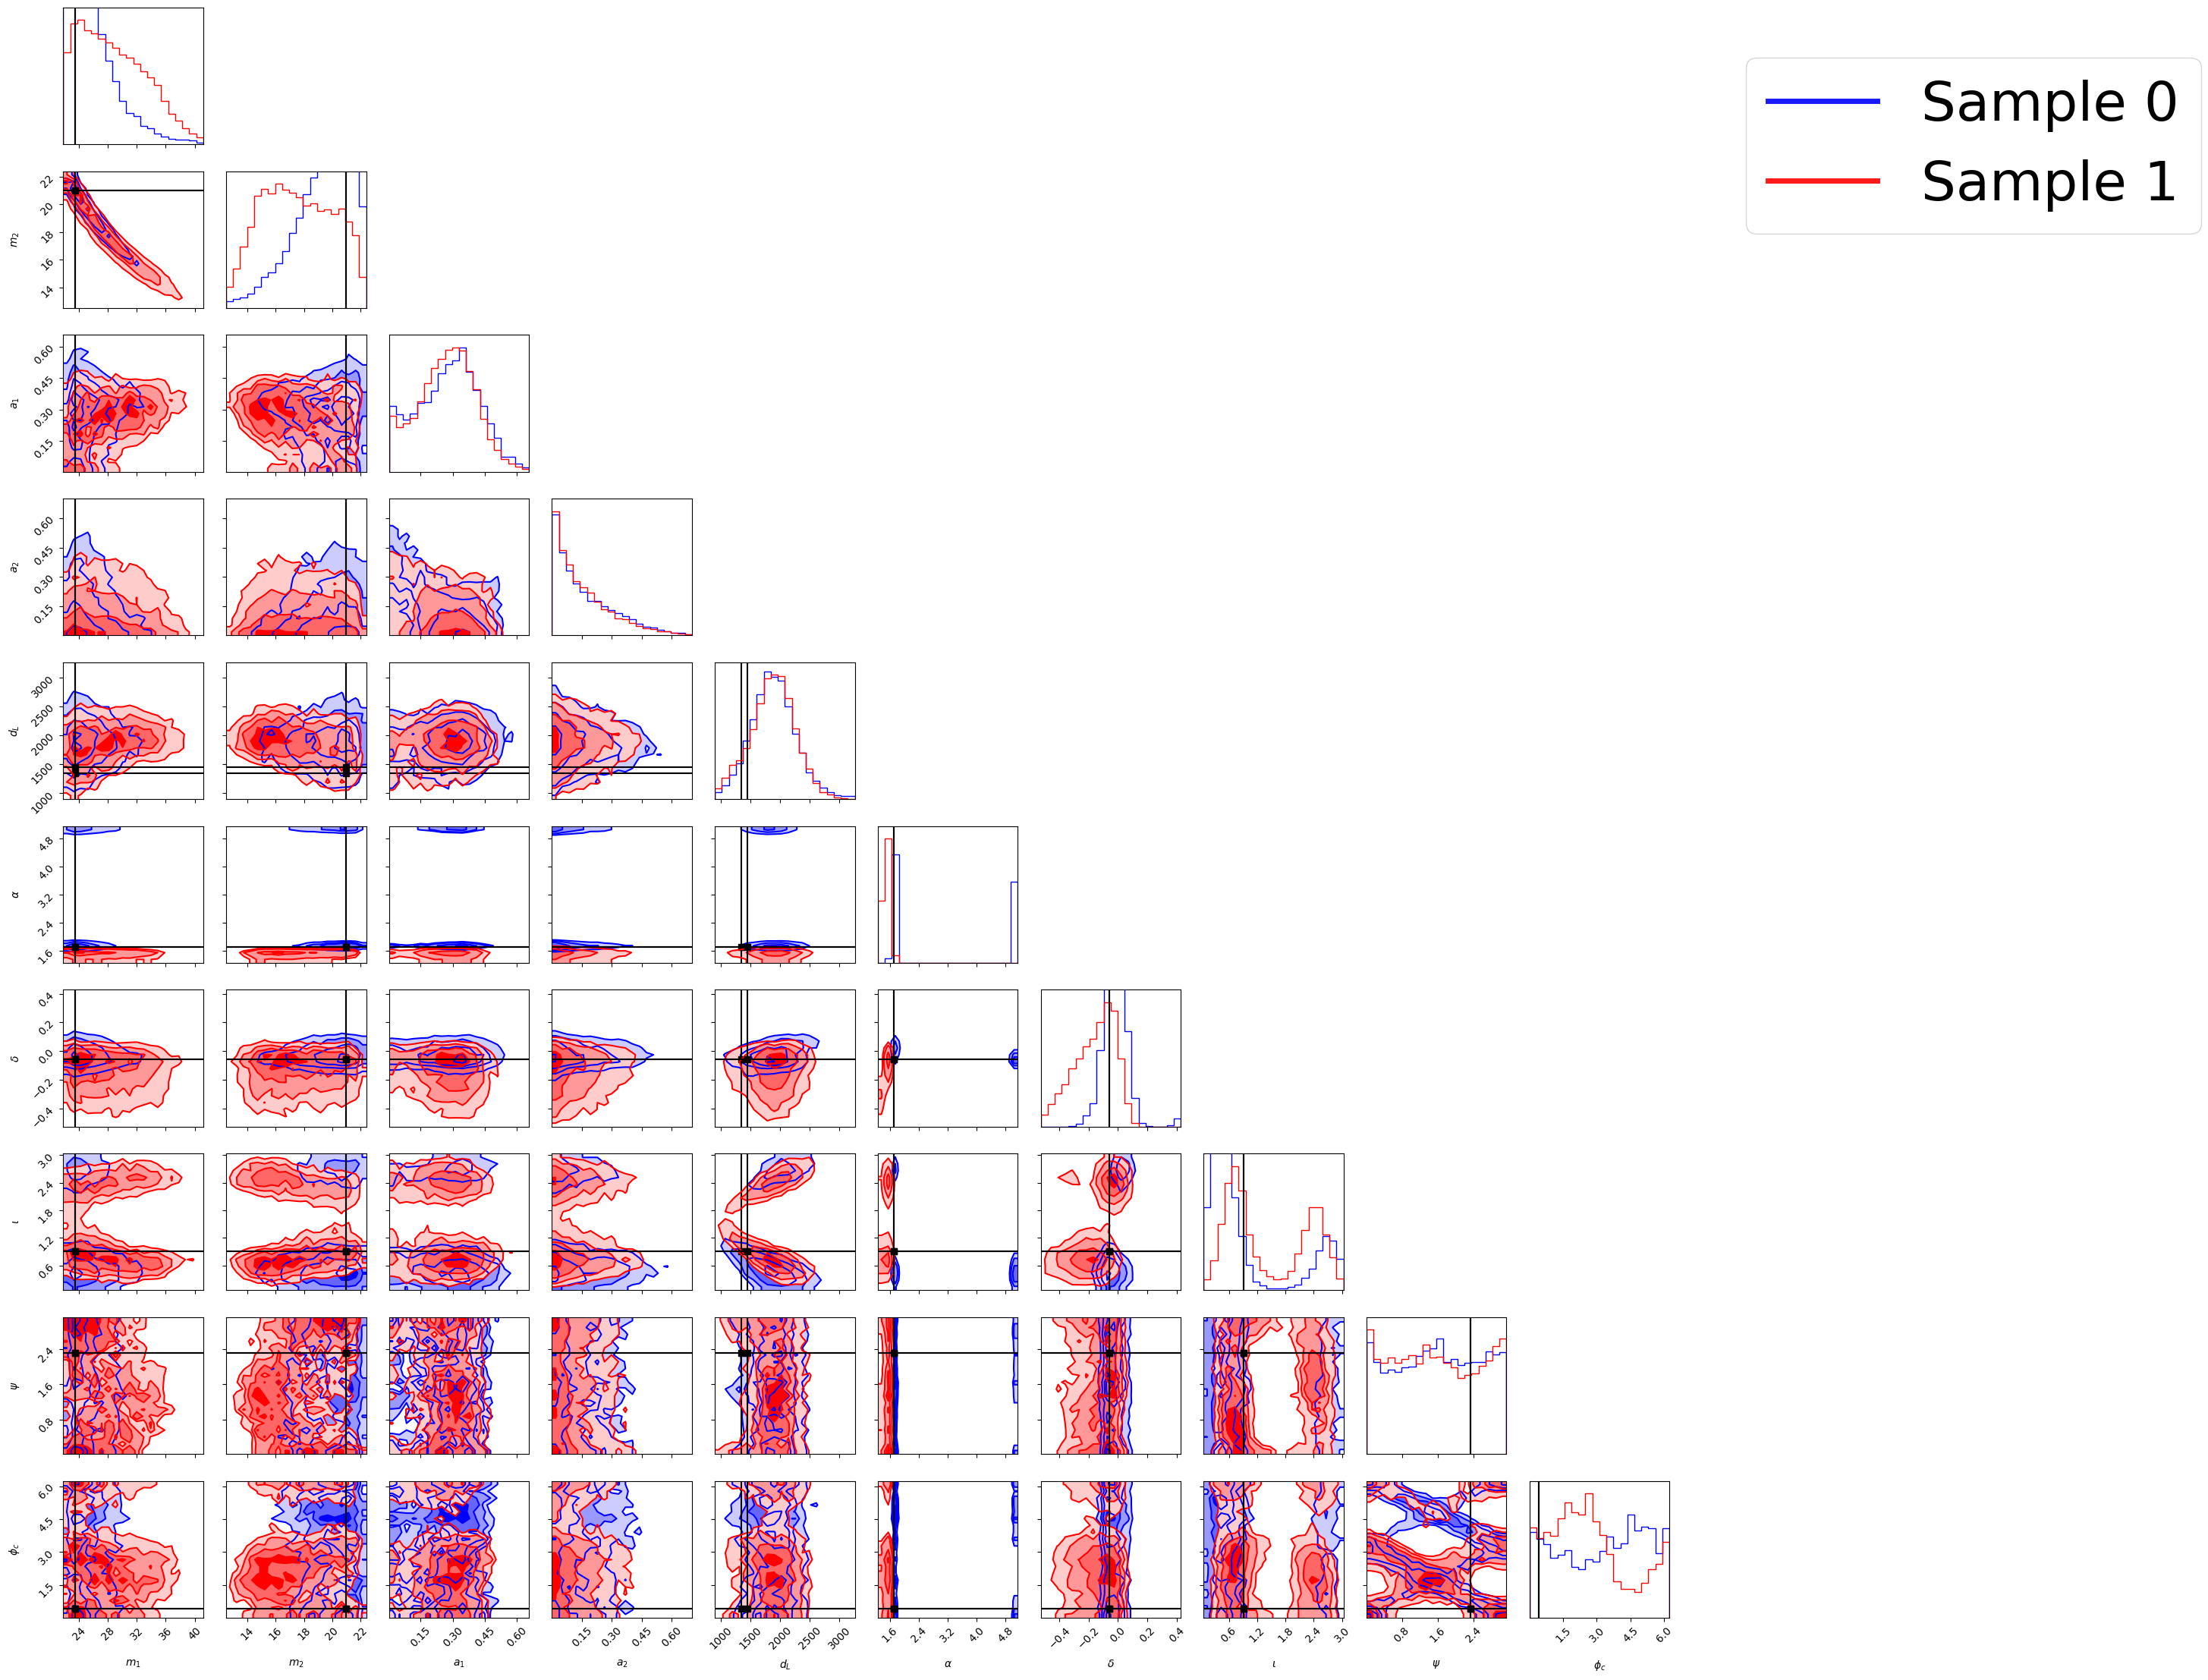

In [86]:
import h5py
import corner
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ================== SETTINGS ==================
files = [
    {'path': 'test/MD_SDSS_l2_9_0_bilby_style_samples.h5', 
     'color': 'blue', 'label': 'Sample 0'},
    {'path': 'test/MD_SDSS_l2_9_1_bilby_style_samples.h5', 
     'color': 'red', 'label': 'Sample 1'}
]

injection_files = [
    'test/MD_SDSS_l2_9_0_injection_values.npy',
    'test/MD_SDSS_l2_9_1_injection_values.npy'
]

target_params = [
    'mass_1', 'mass_2', 'a_1', 'a_2',
    'luminosity_distance', 'ra', 'dec',
    'iota', 'psi', 'phase'
]

my_labels = [
    r'$m_1$', r'$m_2$', r'$a_1$', r'$a_2$',
    r'$d_L$', r'$\alpha$', r'$\delta$',
    r'$\iota$', r'$\psi$', r'$\phi_c$'
]

# Accurate index mapping from your debug output
param_to_index = {
    'iota': 0,
    'ra': 1,
    'dec': 2,
    'psi': 3,
    'mass_1': 4,
    'mass_2': 5,
    'luminosity_distance': 6,
    'phase': 27,
}

# ================== READ SAMPLES ==================
all_data_list = []
raw_data = []
for f_info in files:
    with h5py.File(f_info['path'], 'r') as f:
        all_columns = [name.decode('utf-8') for name in f['df/axis0'][:]]
        sorted_indices = sorted([all_columns.index(p) for p in target_params])
        data_raw_ = f['df/block0_values']
        data = f['df/block0_values'][:, sorted_indices]
        current_indices = [all_columns.index(p) for p in target_params]
        reorder_map = [sorted_indices.index(idx) for idx in current_indices]
        all_data_list.append(data[:, reorder_map])
        raw_data.append(data_raw_)

# Global ranges
combined_data = np.vstack(all_data_list)
ranges = []
for i in range(combined_data.shape[1]):
    d = combined_data[:, i]
    if np.std(d) < 1e-10:
        ranges.append((float(d[0]) - 0.1, float(d[0]) + 0.1))
    else:
        ranges.append((np.percentile(d, 0.5), np.percentile(d, 99.5)))

# ================== READ INJECTION VALUES ==================
truths_list = []
for inj_path in injection_files:
    inj = np.load(inj_path, allow_pickle=True)
    if hasattr(inj, 'ndim') and inj.ndim == 0:
        inj_tuple = inj.item()
    else:
        inj_tuple = inj
    
    truth_values = []
    for param in target_params:
        try:
            idx = param_to_index.get(param)
            if idx is not None and idx < len(inj_tuple):
                val = inj_tuple[idx]
                if isinstance(val, np.ndarray):
                    val = float(val.item() if val.ndim == 0 else val[0])
                else:
                    val = float(val)
                truth_values.append(val)
            else:
                truth_values.append(np.nan)
        except Exception as e:
            print(f"Warning: Could not extract {param}: {e}")
            truth_values.append(np.nan)
    
    truths_list.append(truth_values)

# ================== PLOTTING ==================
fig = None
for i, f_info in enumerate(files):
    fig = corner.corner(  
        all_data_list[i],  
        fig=fig,  labels=my_labels,  
        range=ranges,  
        plot_datapoints=False,  
        fill_contours=True,  
        color=f_info['color'],  
        hist_kwargs={'density': True},  
        truths=truths_list[i],  
        truth_color='black',  
        truth_kwargs={'linestyle': '--', 'linewidth': 1.8},
)

# Legend
legend_lines = [Line2D([0], [0], color=f['color'], lw=5, alpha=0.9)
                for f in files]

fig.legend(
    legend_lines,
    [f['label'] for f in files],
    bbox_to_anchor=(1.02, 0.98),
    loc='upper left',
    frameon=True,
    fontsize=52
)

plt.tight_layout()
plt.savefig('corner_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [69]:
import numpy as np

# Assuming 'all_data_list' is your list of posterior samples (the same list used for corner plotting)
# Assuming 'target_params' is your list of parameter names

for i, f_info in enumerate(files):
    print(f"\n--- Variances for {f_info['label']} ---")
    # Calculate variance for each parameter (column)
    variances = np.var(all_data_list[i], axis=0)
    
    # Print the variance for each parameter
    for param, var in zip(target_params, variances):
        print(f"{param:<20}: {var:.6e}")


--- Variances for Sample 0 ---
mass_1              : 1.199345e+01
mass_2              : 4.255156e+00
a_1                 : 2.162178e-02
a_2                 : 2.433483e-02
tilt_1              : 4.159152e-01
tilt_2              : 2.357053e+00
phi_12              : 0.000000e+00
phi_jl              : 1.534882e+00
luminosity_distance : 1.855812e+05
ra                  : 2.877843e+00
dec                 : 9.194099e-03
iota                : 8.798961e-01
psi                 : 8.270463e-01
geocent_time        : 1.191212e-04
phase               : 3.462848e+00

--- Variances for Sample 1 ---
mass_1              : 2.144943e+01
mass_2              : 6.145416e+00
a_1                 : 1.782793e-02
a_2                 : 2.118232e-02
tilt_1              : 3.962736e-01
tilt_2              : 2.379333e+00
phi_12              : 0.000000e+00
phi_jl              : 2.299064e+00
luminosity_distance : 1.483123e+05
ra                  : 9.181150e-03
dec                 : 2.071264e-02
iota                : 7.34

In [ ]:
plt.hist()

In [90]:
raw_data[0].dtype

ValueError: Invalid dataset identifier (identifier is not of specified type)

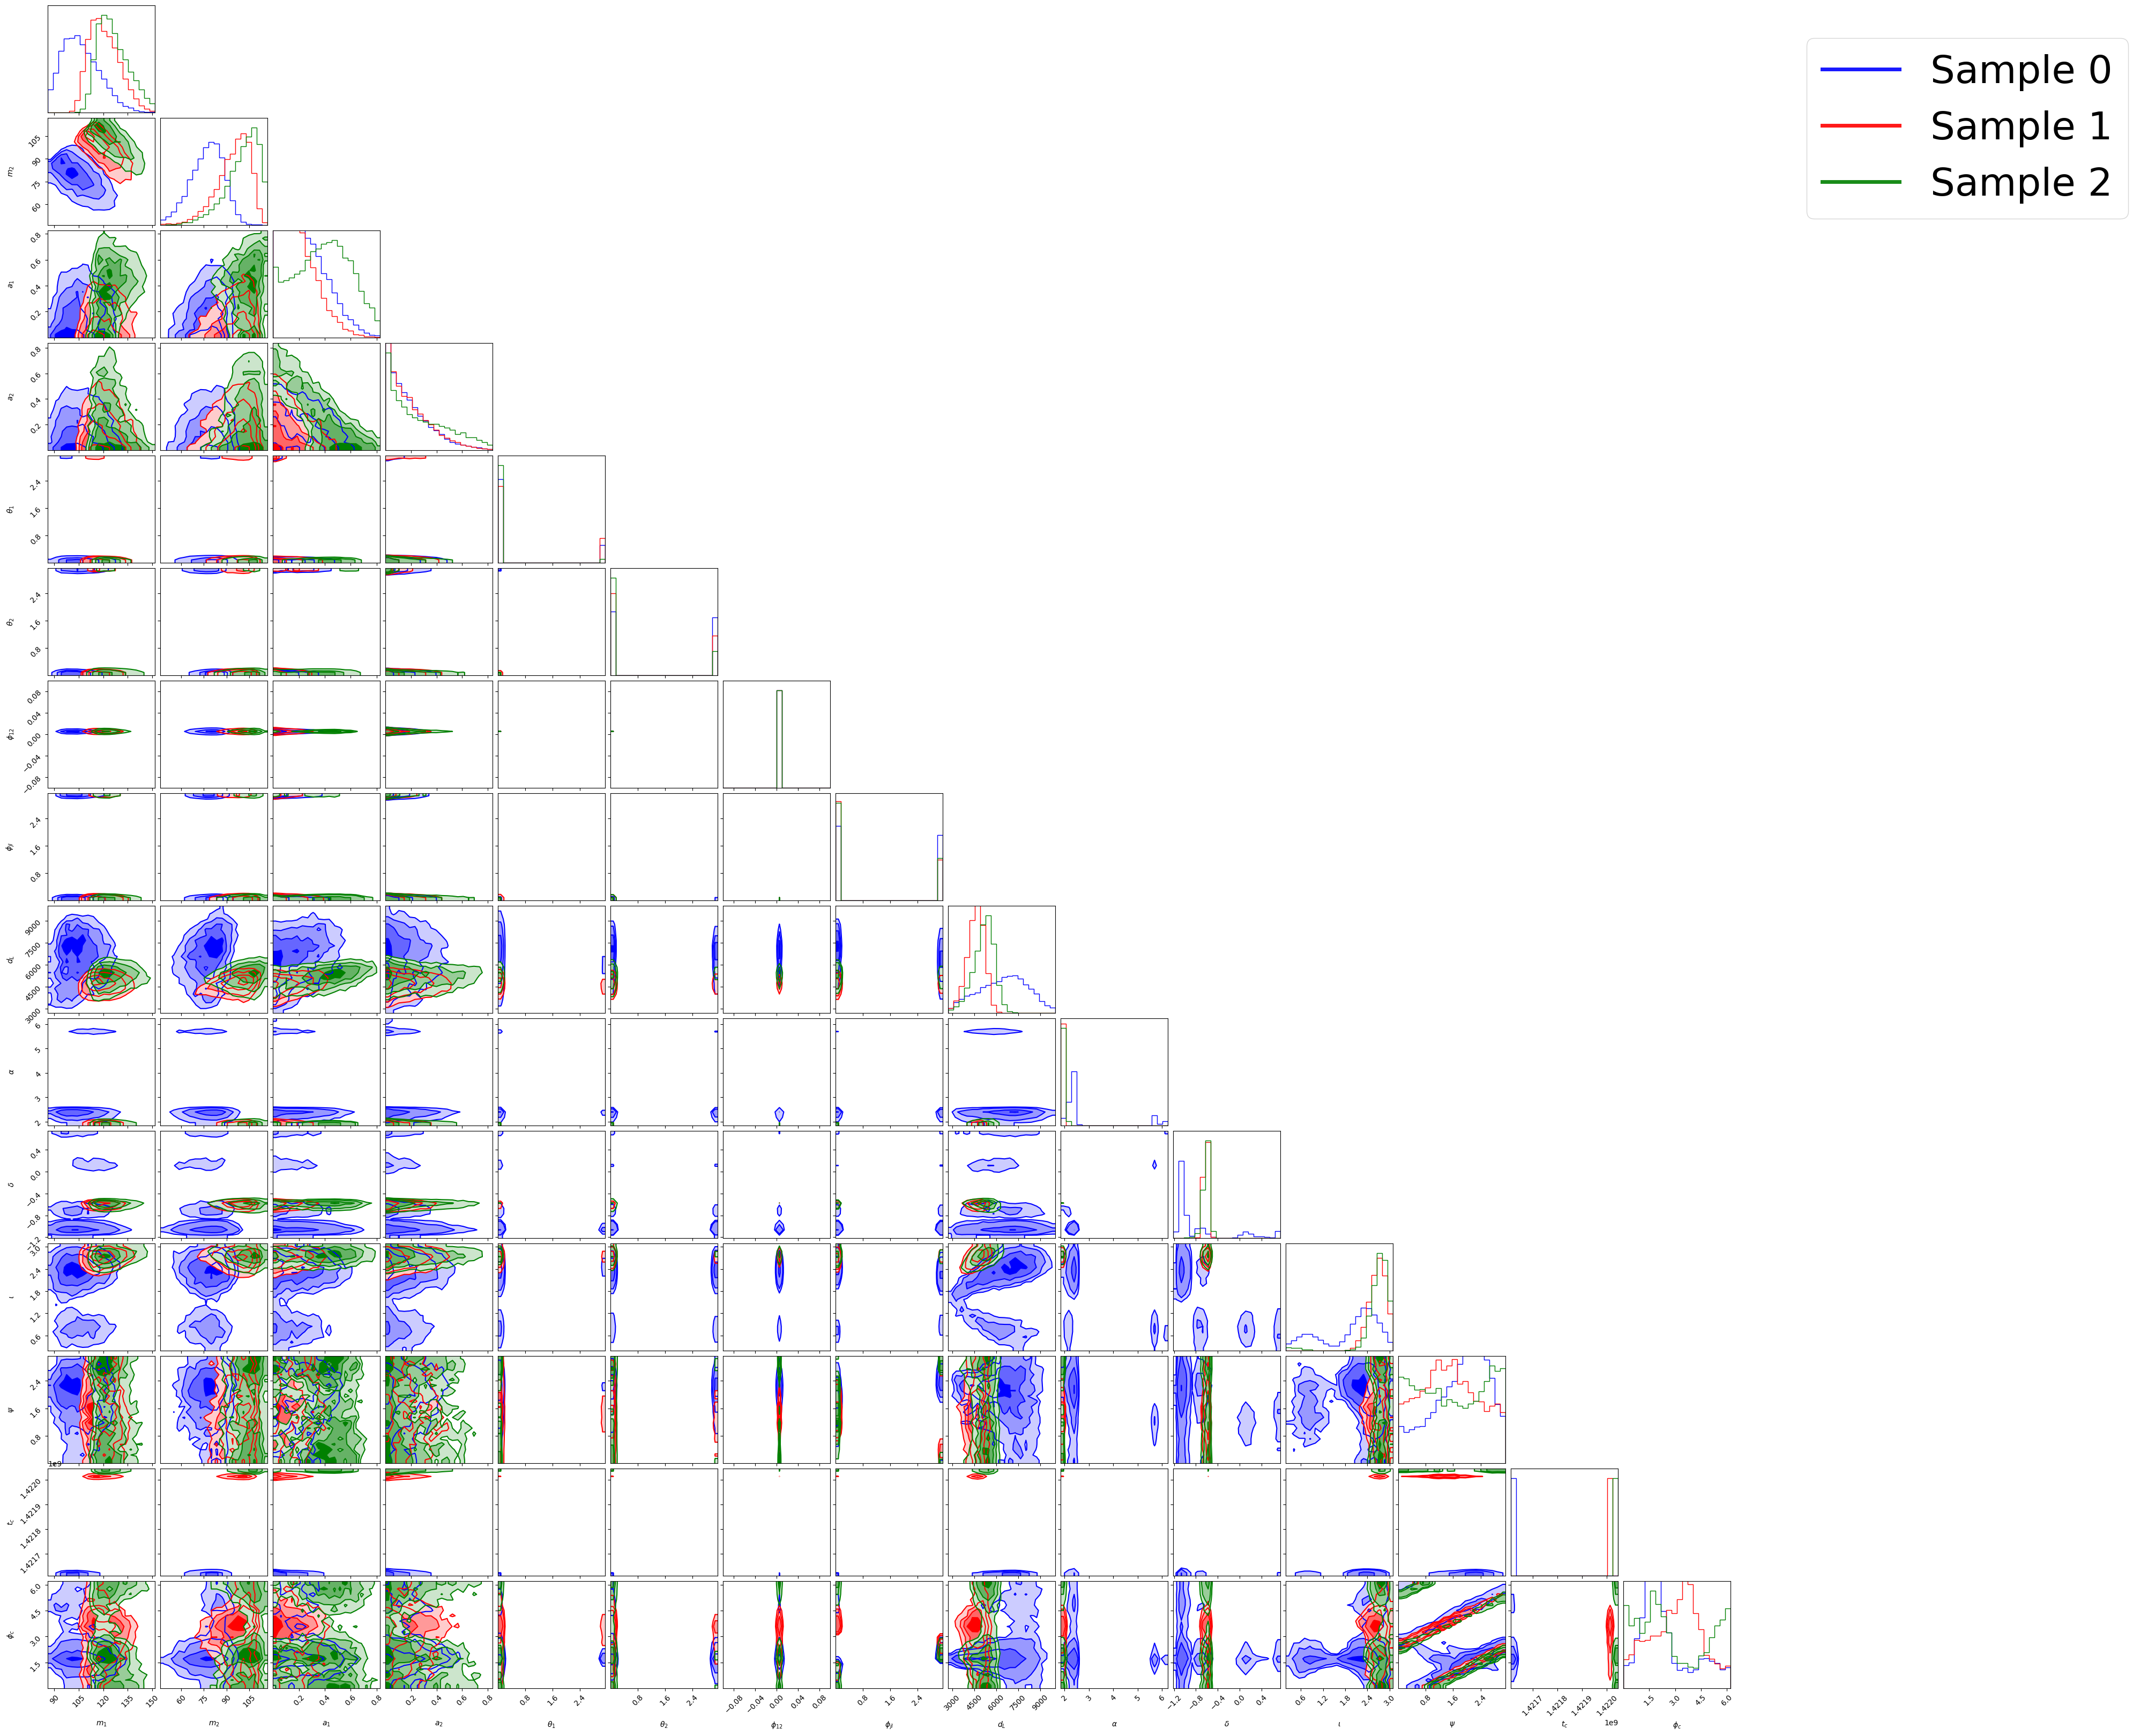

In [ ]:
import h5py
import corner
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 設定檔案與參數
files = [
    {'path': 'test/MD_SDSS_l3_9_0_bilby_style_samples.h5', 'color': 'blue', 'label': 'Sample 0'},
    {'path': 'test/MD_SDSS_l3_9_1_bilby_style_samples.h5', 'color': 'red', 'label': 'Sample 1'},
    {'path': 'test/MD_SDSS_l3_9_2_bilby_style_samples.h5', 'color': 'green', 'label': 'Sample 2'}
]

target_params = [
    'mass_1', 'mass_2', 'a_1', 'a_2', 'tilt_1', 'tilt_2', 
    'phi_12', 'phi_jl', 'luminosity_distance', 'ra', 'dec', 
    'iota', 'psi', 'geocent_time', 'phase'
]

my_labels = [
    r'$m_1$', r'$m_2$', r'$a_1$', r'$a_2$', r'$\theta_1$', r'$\theta_2$', 
    r'$\phi_{12}$', r'$\phi_{jl}$', r'$d_L$', r'$\alpha$', r'$\delta$', 
    r'$\iota$', r'$\psi$', r'$t_c$', r'$\phi_c$'
]

# 1. 預先讀取並計算所有數據的總範圍，確保兩組數據都能顯示
all_data_list = []
for f_info in files:
    with h5py.File(f_info['path'], 'r') as f:
        all_columns = [name.decode('utf-8') for name in f['df/axis0'][:]]
        sorted_indices = sorted([all_columns.index(p) for p in target_params])
        data = f['df/block0_values'][:, sorted_indices]
        current_indices = [all_columns.index(p) for p in target_params]
        reorder_map = [sorted_indices.index(idx) for idx in current_indices]
        all_data_list.append(data[:, reorder_map])

# 計算每個參數的全局範圍 (0.5% 到 99.5% 分位數)
combined_data = np.vstack(all_data_list)
ranges = []
for i in range(combined_data.shape[1]):
    d = combined_data[:, i]
    if d.std() == 0:
        ranges.append((d[0] - 0.1, d[0] + 0.1))
    else:
        # 使用分位數定義範圍，避免極端異常值干擾
        ranges.append((np.percentile(d, 0.5), np.percentile(d, 99.5)))

# 2. 進行繪圖
fig = None
for i, f_info in enumerate(files):
    fig = corner.corner(
        all_data_list[i],
        fig=fig,
        labels=my_labels,
        range=ranges,  # 關鍵：強制設定相同範圍
        plot_datapoints=False,
        fill_contours=True,
        color=f_info['color'],
        hist_kwargs={'density': True}
    )

# 3. 加入圖例
legend_lines = [
    Line2D([0], [0], color=f['color'], lw=4, alpha=0.9) 
    for f in files
]

legend_lines = [
    Line2D([0], [0], color=f['color'], lw=4, alpha=0.85) 
    for f in files
]

legend_lines = [Line2D([0], [0], color=f['color'], lw=5, alpha=0.9) 
                for f in files]

# Use fig.legend instead of plt.legend for better control
fig.legend(
    legend_lines,
    [f['label'] for f in files],
    bbox_to_anchor=(1.02, 0.98),
    loc='upper left',
    frameon=True,
    fontsize=52
)

plt.show()

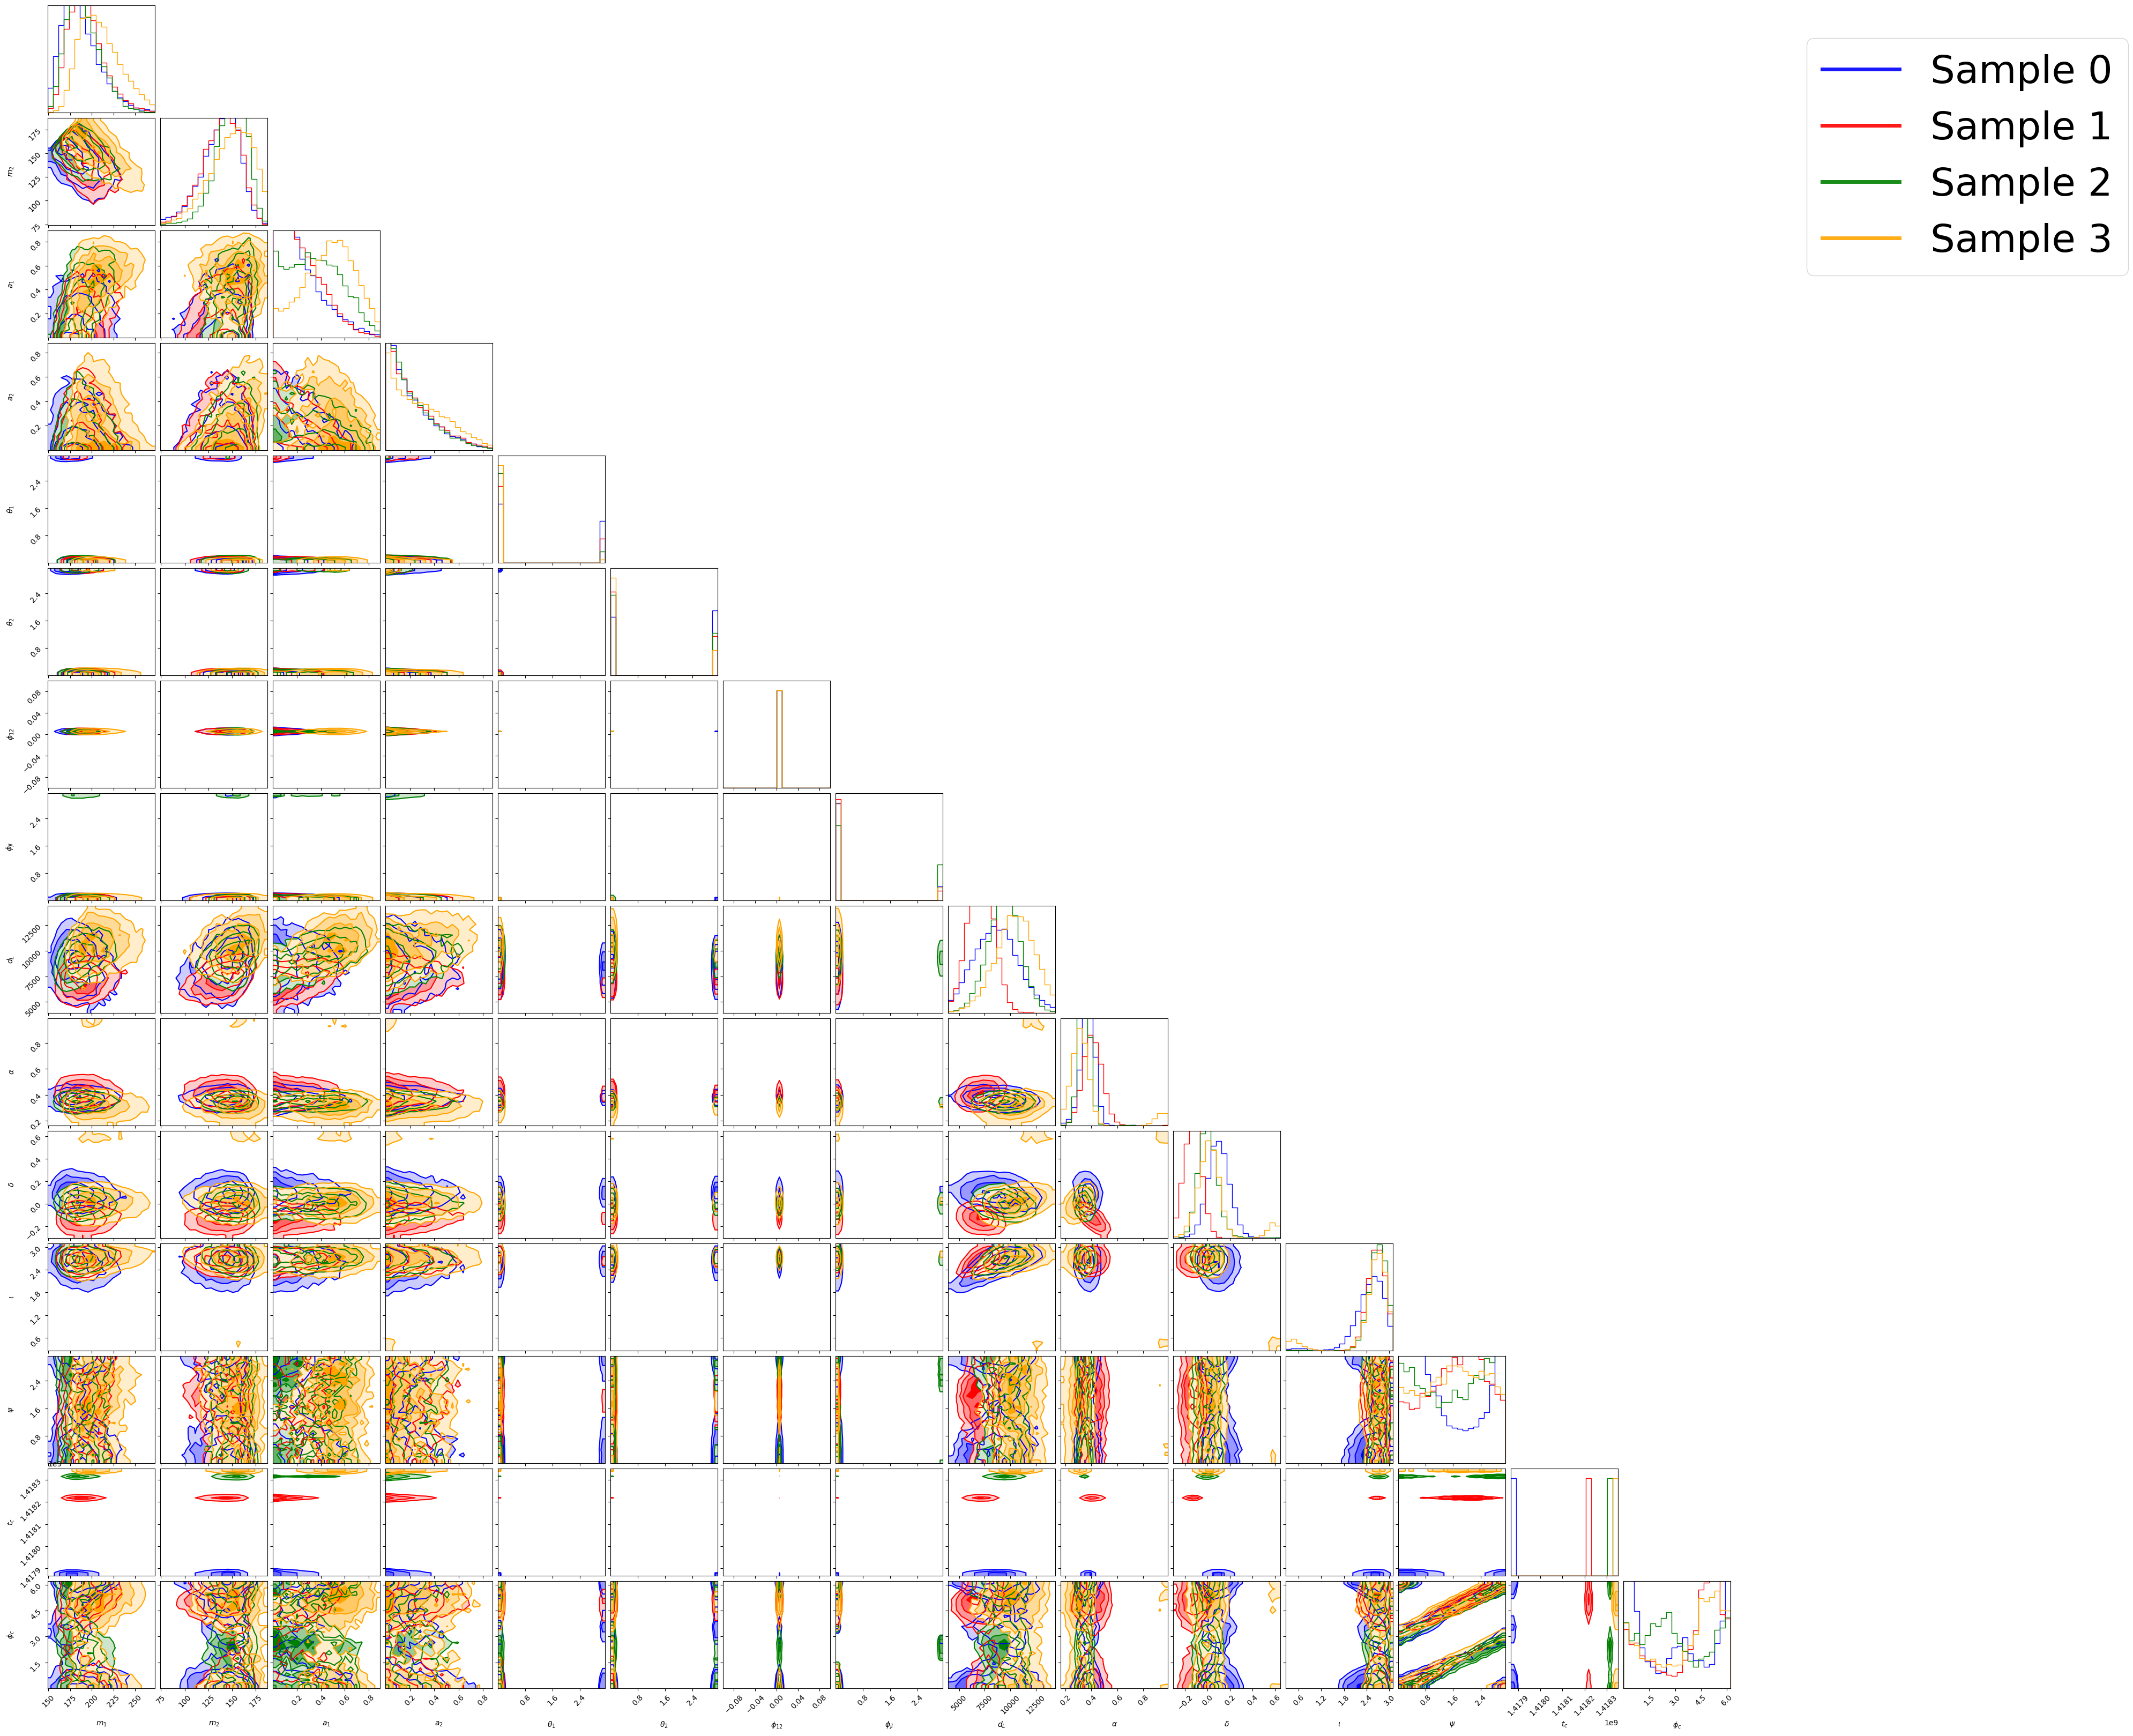

In [15]:
import h5py
import corner
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 設定檔案與參數
files = [
    {'path': 'test/MD_SDSS_l4_9_0_bilby_style_samples.h5', 'color': 'blue', 'label': 'Sample 0'},
    {'path': 'test/MD_SDSS_l4_9_1_bilby_style_samples.h5', 'color': 'red', 'label': 'Sample 1'},
    {'path': 'test/MD_SDSS_l4_9_2_bilby_style_samples.h5', 'color': 'green', 'label': 'Sample 2'},
    {'path': 'test/MD_SDSS_l4_9_3_bilby_style_samples.h5', 'color': 'orange', 'label': 'Sample 3'}
]

target_params = [
    'mass_1', 'mass_2', 'a_1', 'a_2', 'tilt_1', 'tilt_2', 
    'phi_12', 'phi_jl', 'luminosity_distance', 'ra', 'dec', 
    'iota', 'psi', 'geocent_time', 'phase'
]

my_labels = [
    r'$m_1$', r'$m_2$', r'$a_1$', r'$a_2$', r'$\theta_1$', r'$\theta_2$', 
    r'$\phi_{12}$', r'$\phi_{jl}$', r'$d_L$', r'$\alpha$', r'$\delta$', 
    r'$\iota$', r'$\psi$', r'$t_c$', r'$\phi_c$'
]

# 1. 預先讀取並計算所有數據的總範圍，確保兩組數據都能顯示
all_data_list = []
for f_info in files:
    with h5py.File(f_info['path'], 'r') as f:
        all_columns = [name.decode('utf-8') for name in f['df/axis0'][:]]
        sorted_indices = sorted([all_columns.index(p) for p in target_params])
        data = f['df/block0_values'][:, sorted_indices]
        current_indices = [all_columns.index(p) for p in target_params]
        reorder_map = [sorted_indices.index(idx) for idx in current_indices]
        all_data_list.append(data[:, reorder_map])

# 計算每個參數的全局範圍 (0.5% 到 99.5% 分位數)
combined_data = np.vstack(all_data_list)
ranges = []
for i in range(combined_data.shape[1]):
    d = combined_data[:, i]
    if d.std() == 0:
        ranges.append((d[0] - 0.1, d[0] + 0.1))
    else:
        # 使用分位數定義範圍，避免極端異常值干擾
        ranges.append((np.percentile(d, 0.5), np.percentile(d, 99.5)))

# 2. 進行繪圖
fig = None
for i, f_info in enumerate(files):
    fig = corner.corner(
        all_data_list[i],
        fig=fig,
        labels=my_labels,
        range=ranges,  # 關鍵：強制設定相同範圍
        plot_datapoints=False,
        fill_contours=True,
        color=f_info['color'],
        hist_kwargs={'density': True}
    )

# 3. 加入圖例
legend_lines = [
    Line2D([0], [0], color=f['color'], lw=4, alpha=0.9) 
    for f in files
]

legend_lines = [
    Line2D([0], [0], color=f['color'], lw=4, alpha=0.85) 
    for f in files
]

legend_lines = [Line2D([0], [0], color=f['color'], lw=5, alpha=0.9) 
                for f in files]

# Use fig.legend instead of plt.legend for better control
fig.legend(
    legend_lines,
    [f['label'] for f in files],
    bbox_to_anchor=(1.02, 0.98),
    loc='upper left',
    frameon=True,
    fontsize=52
)

plt.show()

In [24]:
import numpy as np
data_0 = np.load('test/MD_SDSS_l2_9_0_injection_values.npy')
data_1 = np.load('test/MD_SDSS_l2_9_1_injection_values.npy')
print(data_0)
print(data_1)

(0.916868459797618, 1.711040767888596, -0.0572370599319676, 2.322280779933076, 23.462851397489057, 20.98574650439168, 1347.9313611443456, 20.0, 0.3117832584981657, 0.0621250467080972, 0.0, 0.0, 9.019837587468343, 0.0, 44.44859790188074, 19.311300163380782, 0.8944243881047437, 0.25719422239754824, 18.66286925240869, 16.69252541136448, 15.360633877677962, 35.35539466377317, 0.26938626512762304, 0.3222808939386668, -0.060906389113347295, 0.032022143057967835, 0.645324700519384, 0.42004039619698036, 0.0688113790070467, 0.523108721698511, 0.09270667348866903, 1.2537270593738334, 1.5086312483630995, 0.19391083523451938, 0.42004039619698036, 'IMRPhenomXPHM', [5.341005872125045, 68.85239537356229, 16.79933028850248], [4.744010823172729, 70.76981419293995, 13.668424241156197])
(0.916868459797618, 1.711040767888596, -0.0572370599319676, 2.322280779933076, 23.462851397489057, 20.98574650439168, 1448.5943495608565, 20.0, 0.3117832584981657, 0.0621250467080972, 0.0, 0.0, 10.5560622575907, 0.0, 44.4

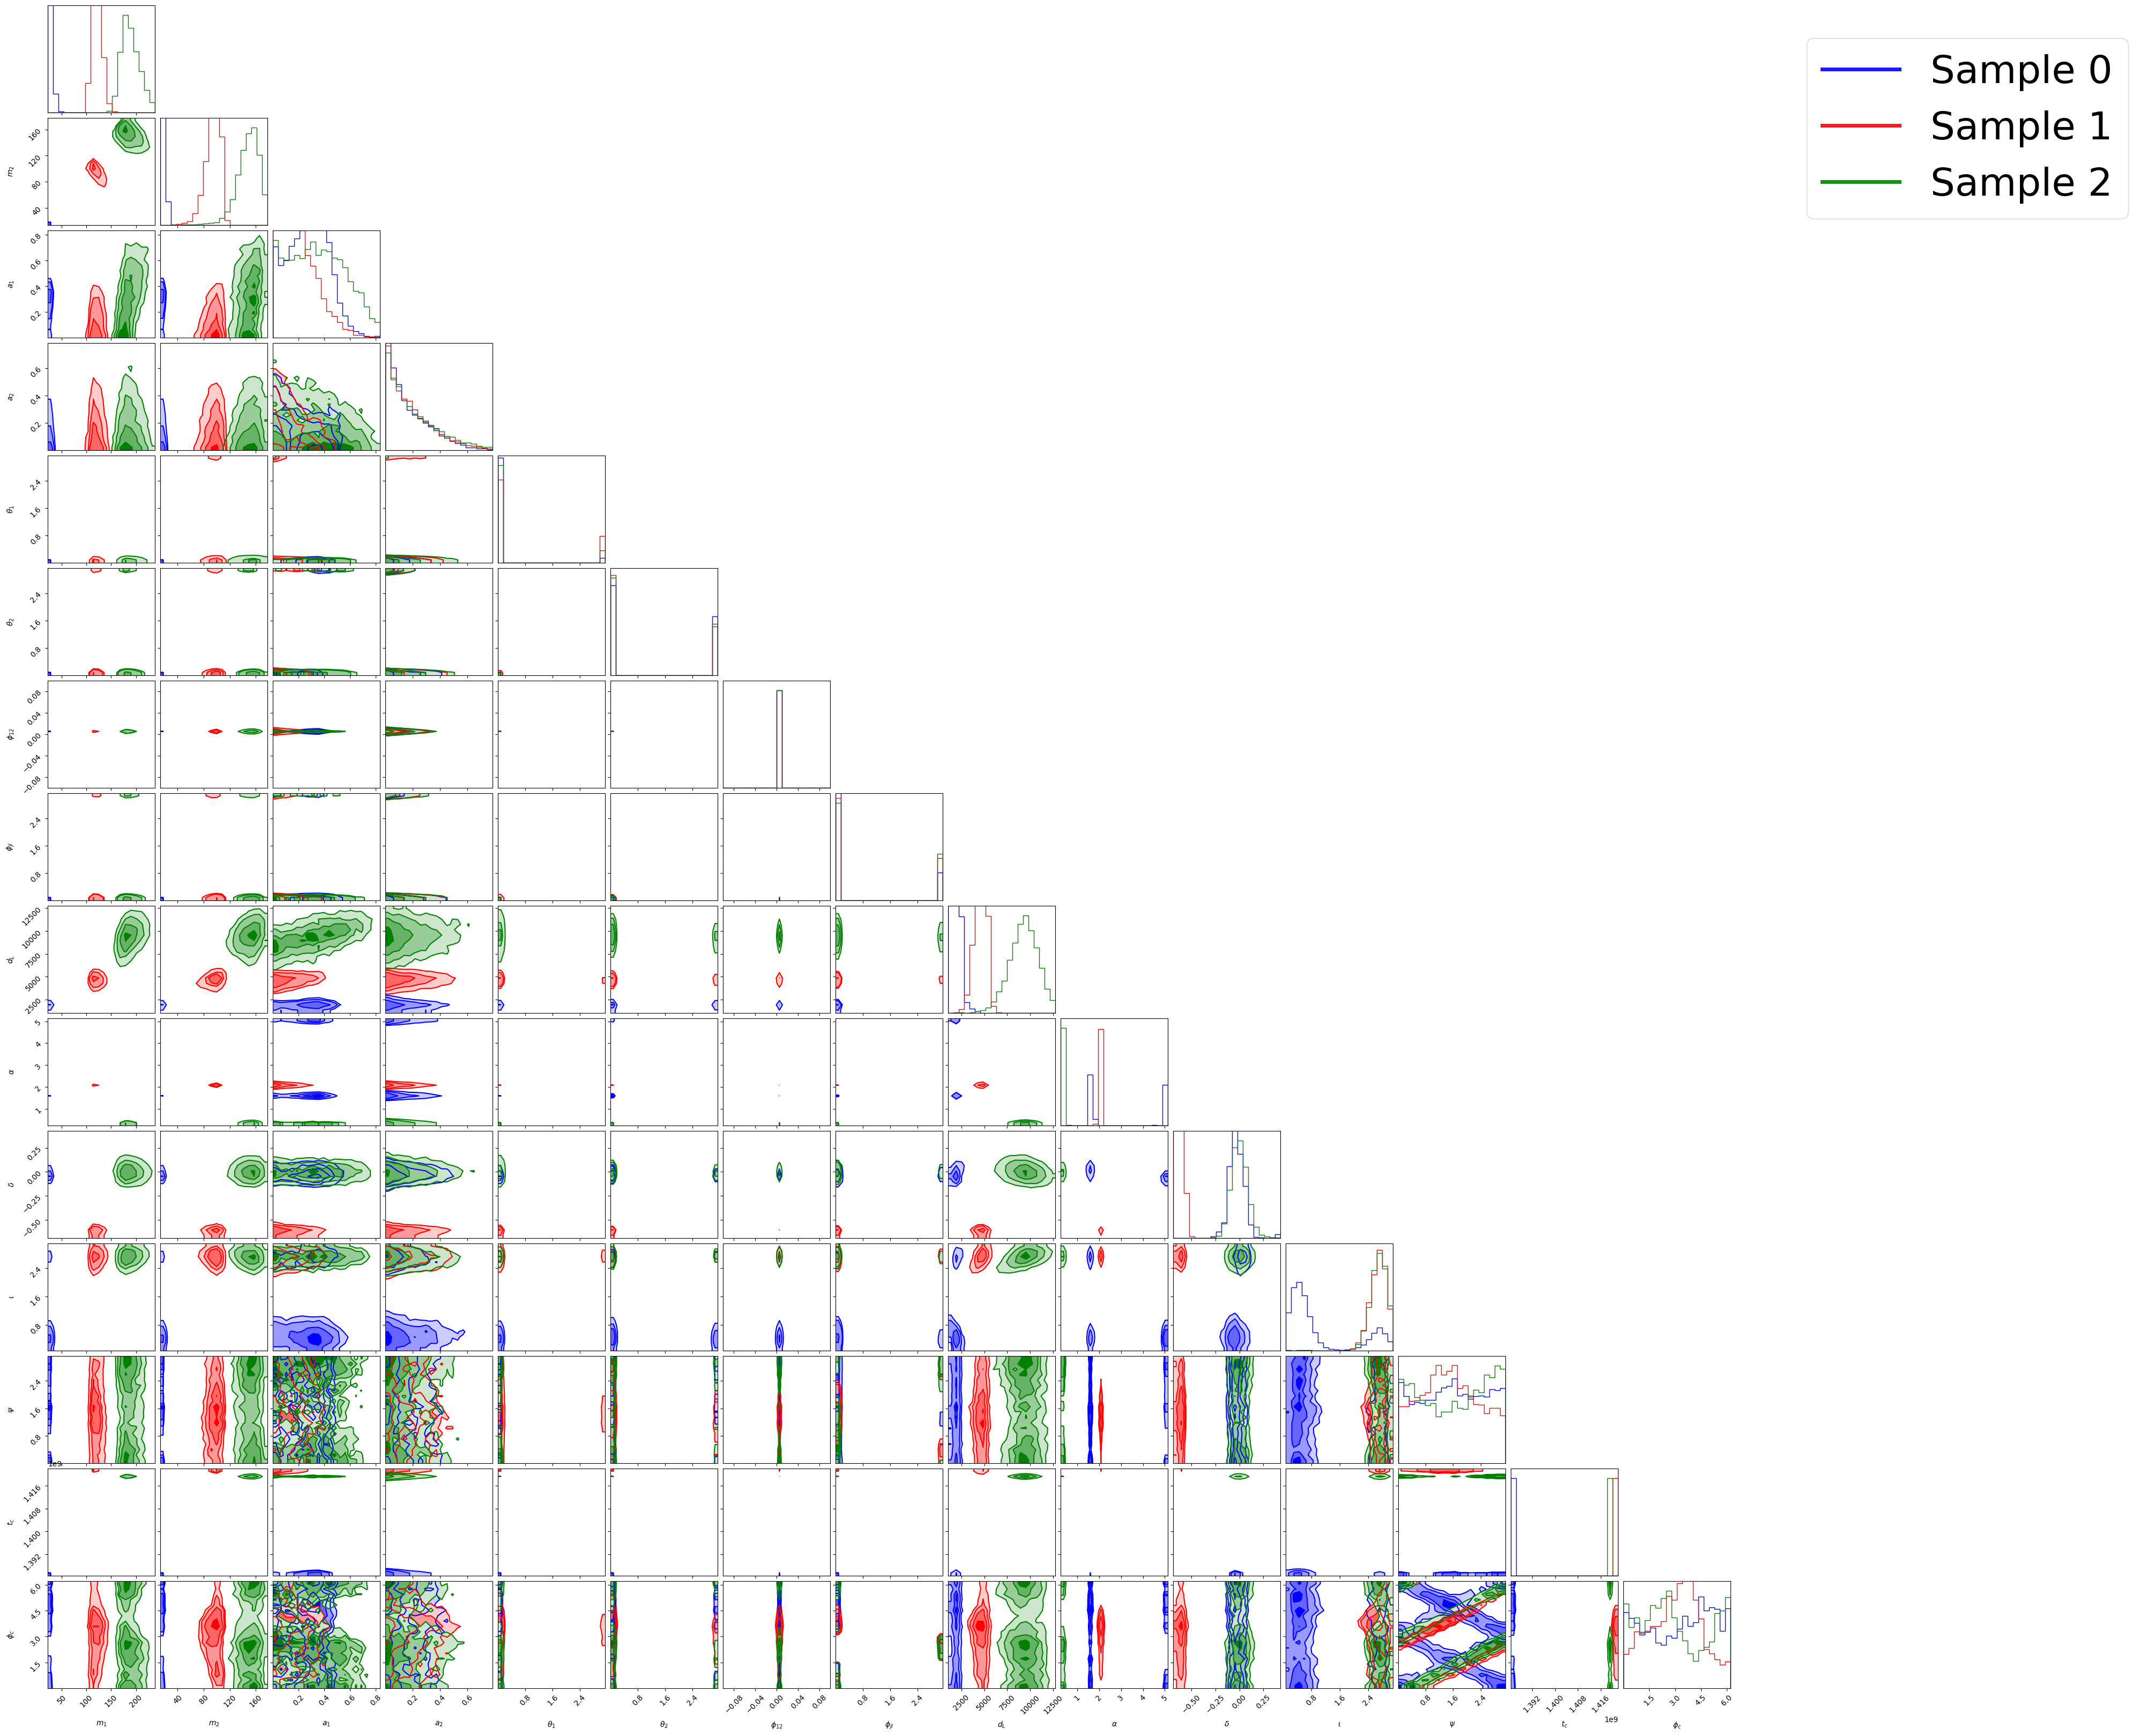

In [36]:
import h5py
import corner
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 設定檔案與參數
files = [
    {'path': 'test/MD_SDSS_l2_9_0_bilby_style_samples.h5', 'color': 'blue', 'label': 'Sample 0'},
    {'path': 'test/MD_SDSS_l3_9_1_bilby_style_samples.h5', 'color': 'red', 'label': 'Sample 1'},
    {'path': 'test/MD_SDSS_l4_9_2_bilby_style_samples.h5', 'color': 'green', 'label': 'Sample 2'}
]

target_params = [
    'mass_1', 'mass_2', 'a_1', 'a_2', 'tilt_1', 'tilt_2', 
    'phi_12', 'phi_jl', 'luminosity_distance', 'ra', 'dec', 
    'iota', 'psi', 'geocent_time', 'phase'
]

my_labels = [
    r'$m_1$', r'$m_2$', r'$a_1$', r'$a_2$', r'$\theta_1$', r'$\theta_2$', 
    r'$\phi_{12}$', r'$\phi_{jl}$', r'$d_L$', r'$\alpha$', r'$\delta$', 
    r'$\iota$', r'$\psi$', r'$t_c$', r'$\phi_c$'
]

# 1. 預先讀取並計算所有數據的總範圍，確保兩組數據都能顯示
all_data_list = []
for f_info in files:
    with h5py.File(f_info['path'], 'r') as f:
        all_columns = [name.decode('utf-8') for name in f['df/axis0'][:]]
        sorted_indices = sorted([all_columns.index(p) for p in target_params])
        data = f['df/block0_values'][:, sorted_indices]
        current_indices = [all_columns.index(p) for p in target_params]
        reorder_map = [sorted_indices.index(idx) for idx in current_indices]
        all_data_list.append(data[:, reorder_map])

# 計算每個參數的全局範圍 (0.5% 到 99.5% 分位數)
combined_data = np.vstack(all_data_list)
ranges = []
for i in range(combined_data.shape[1]):
    d = combined_data[:, i]
    if d.std() == 0:
        ranges.append((d[0] - 0.1, d[0] + 0.1))
    else:
        # 使用分位數定義範圍，避免極端異常值干擾
        ranges.append((np.percentile(d, 0.5), np.percentile(d, 99.5)))

# 2. 進行繪圖
fig = None
for i, f_info in enumerate(files):
    fig = corner.corner(
        all_data_list[i],
        fig=fig,
        labels=my_labels,
        range=ranges,  # 關鍵：強制設定相同範圍
        plot_datapoints=False,
        fill_contours=True,
        color=f_info['color'],
        hist_kwargs={'density': True}
    )

# 3. 加入圖例
legend_lines = [
    Line2D([0], [0], color=f['color'], lw=4, alpha=0.9) 
    for f in files
]

legend_lines = [
    Line2D([0], [0], color=f['color'], lw=4, alpha=0.85) 
    for f in files
]

legend_lines = [Line2D([0], [0], color=f['color'], lw=5, alpha=0.9) 
                for f in files]

# Use fig.legend instead of plt.legend for better control
fig.legend(
    legend_lines,
    [f['label'] for f in files],
    bbox_to_anchor=(1.02, 0.98),
    loc='upper left',
    frameon=True,
    fontsize=52
)

plt.show()